# Predicting Fetal Distress: Classifying Fetal Health from Cardiotocography Data

**Author:** Angela Mukami, Catherine Nanjala, Moffat Mwangi, Tafford Pessah

---

## 1. Business Understanding

Monitoring fetal health during pregnancy is critical to ensure both maternal and fetal well-being. One of the most common methods for evaluating fetal health is Cardiotocography (CTG), which measures fetal heart rate and uterine contractions. Abnormalities in CTG readings can indicate potential fetal distress, requiring immediate intervention to prevent complications during labour and delivery.

However, interpreting CTG data is complex and subject to inter-observer variability -- different clinicians can interpret the same trace differently. An automated classification system that reliably identifies fetal distress from CTG measurements could assist healthcare providers in making faster, more consistent decisions.

### The predictive question

> Using Cardiotocography (CTG) measurements -- fetal heart rate patterns, uterine contractions, decelerations, and variability indicators -- can we classify fetal health status as Normal, Suspected, or Abnormal?

This would be useful because early and accurate classification of fetal health enables timely clinical intervention for high-risk pregnancies, potentially reducing adverse outcomes for both mother and baby.

### Who would use this?

- **Healthcare providers**: An automated tool to assist in interpreting CTG data, enabling faster assessment of fetal health and more consistent decision-making across clinicians.
- **Medical researchers**: Exploring which CTG measurements are most strongly associated with fetal distress, advancing knowledge in obstetrics and maternal-fetal medicine.
- **Hospital systems**: Reducing unnecessary interventions by accurately distinguishing normal cases from those requiring action, while ensuring genuinely at-risk cases are not missed.

### Domain context

Cardiotocography has been a standard tool in obstetric care since the 1960s. While it is widely used, its interpretation remains subjective. Studies have shown significant inter-observer and intra-observer variability in CTG interpretation, which can lead to both over-intervention (unnecessary caesarean sections) and under-intervention (missed fetal distress). Machine learning approaches to CTG classification aim to reduce this variability by providing consistent, data-driven assessments.

A critical consideration in this domain is the asymmetry of errors. In clinical terms, a false negative on an Abnormal case -- classifying a distressed fetus as normal -- is far more dangerous than a false positive. This shapes our evaluation strategy: we prioritise recall on the Abnormal class over raw accuracy.

Source: Ayres-de-Campos, D., et al. (2015). FIGO consensus guidelines on intrapartum fetal monitoring: Cardiotocography. International Journal of Gynecology & Obstetrics, 131(1), 13-24.

## 2. Data Understanding

### 2.1 Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, recall_score
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 25)

print("All imports loaded successfully.")

All imports loaded successfully.


### 2.2 Load the dataset

The dataset contains 2,126 Cardiotocography (CTG) records. Each record includes 21 features measuring fetal heart rate patterns, uterine contractions, decelerations, variability indicators, and histogram-derived statistics. The target variable is fetal health status classified into three categories.

In [2]:
df = pd.read_csv('fetal_health.csv')
print(f"Dataset shape: {df.shape[0]} records, {df.shape[1]} columns")
df.head()

Dataset shape: 2126 records, 22 columns


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


### 2.3 Initial data inspection

In [3]:
print("Column names and data types:")
print(df.dtypes)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values found.")

Column names and data types:
baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                      

In [4]:
print("Descriptive statistics:\n")
df.describe().round(2)

Descriptive statistics:



,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.00,2126.00,2126.00,2126.00,2126.00,2126.0,2126.0,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00
mean,133.30,0.00,0.01,0.00,0.00,0.0,0.0,46.99,1.33,9.85,8.19,70.45,93.58,164.03,4.07,0.32,137.45,134.61,138.09,18.81,0.32,1.30
std,9.84,0.00,0.05,0.00,0.00,0.0,0.0,17.19,0.88,18.40,5.63,38.96,29.56,17.94,2.95,0.71,16.38,15.59,14.47,28.98,0.61,0.61
min,106.00,0.00,0.00,0.00,0.00,0.0,0.0,12.00,0.20,0.00,0.00,3.00,50.00,122.00,0.00,0.00,60.00,73.00,77.00,0.00,-1.00,1.00
25%,126.00,0.00,0.00,0.00,0.00,0.0,0.0,32.00,0.70,0.00,4.60,37.00,67.00,152.00,2.00,0.00,129.00,125.00,129.00,2.00,0.00,1.00
50%,133.00,0.00,0.00,0.00,0.00,0.0,0.0,49.00,1.20,0.00,7.40,67.50,93.00,162.00,3.00,0.00,139.00,136.00,139.00,7.00,0.00,1.00
75%,140.00,0.01,0.00,0.01,0.00,0.0,0.0,61.00,1.70,11.00,10.80,100.00,120.00,174.00,6.00,0.00,148.00,145.00,148.00,24.00,1.00,1.00
max,160.00,0.02,0.48,0.02,0.02,0.0,0.0,87.00,7.00,91.00,50.70,180.00,159.00,238.00,18.00,10.00,187.00,182.00,186.00,269.00,1.00,3.00


### 2.4 Target variable distribution

In [5]:
target_counts = df['fetal_health'].value_counts().sort_index()
target_pcts = (df['fetal_health'].value_counts(normalize=True).sort_index() * 100).round(1)

label_map = {1.0: 'Normal', 2.0: 'Suspected', 3.0: 'Abnormal'}

print("Fetal Health Class Distribution:")
print("-" * 40)
for cls in [1.0, 2.0, 3.0]:
    print(f"  {label_map[cls]} (Class {int(cls)}): {target_counts[cls]} records ({target_pcts[cls]}%)")
print(f"\nTotal records: {len(df)}")

Fetal Health Class Distribution:
----------------------------------------
  Normal (Class 1): 1655 records (77.8%)
  Suspected (Class 2): 295 records (13.9%)
  Abnormal (Class 3): 176 records (8.3%)

Total records: 2126


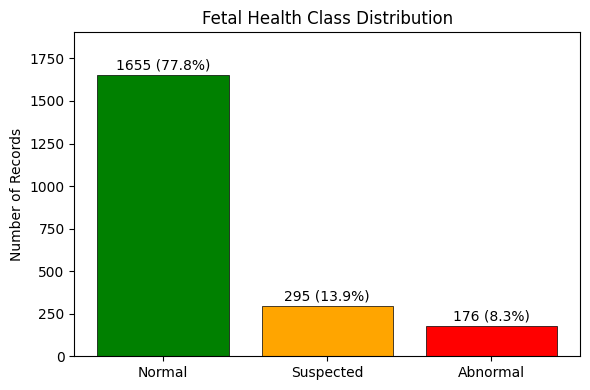

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['green', 'orange', 'red']
class_names = ['Normal', 'Suspected', 'Abnormal']
counts = [target_counts[c] for c in [1.0, 2.0, 3.0]]

bars = ax.bar(class_names, counts, color=colors, edgecolor='black', linewidth=0.5)

for bar, count, pct in zip(bars, counts, [target_pcts[c] for c in [1.0, 2.0, 3.0]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"{count} ({pct}%)", ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Number of Records')
ax.set_title('Fetal Health Class Distribution')
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

The dataset has a severe class imbalance. Normal cases dominate at 77.8%, Suspected cases make up 13.9%, and Abnormal cases are only 8.3% of the data. This imbalance is typical of clinical datasets -- most pregnancies are healthy, and pathological cases are relatively rare.

This has important implications for modelling:

- A naive model that predicts "Normal" for every case would achieve roughly 78% accuracy -- our models must substantially beat this baseline.
- Accuracy alone is misleading. We will use macro F1 as the primary comparison metric, which weights all three classes equally.
- We pay special attention to recall on the Abnormal class (Class 3), because in a clinical setting, missing a case of fetal distress is far more dangerous than a false alarm.


### 2.5 Correlation analysis

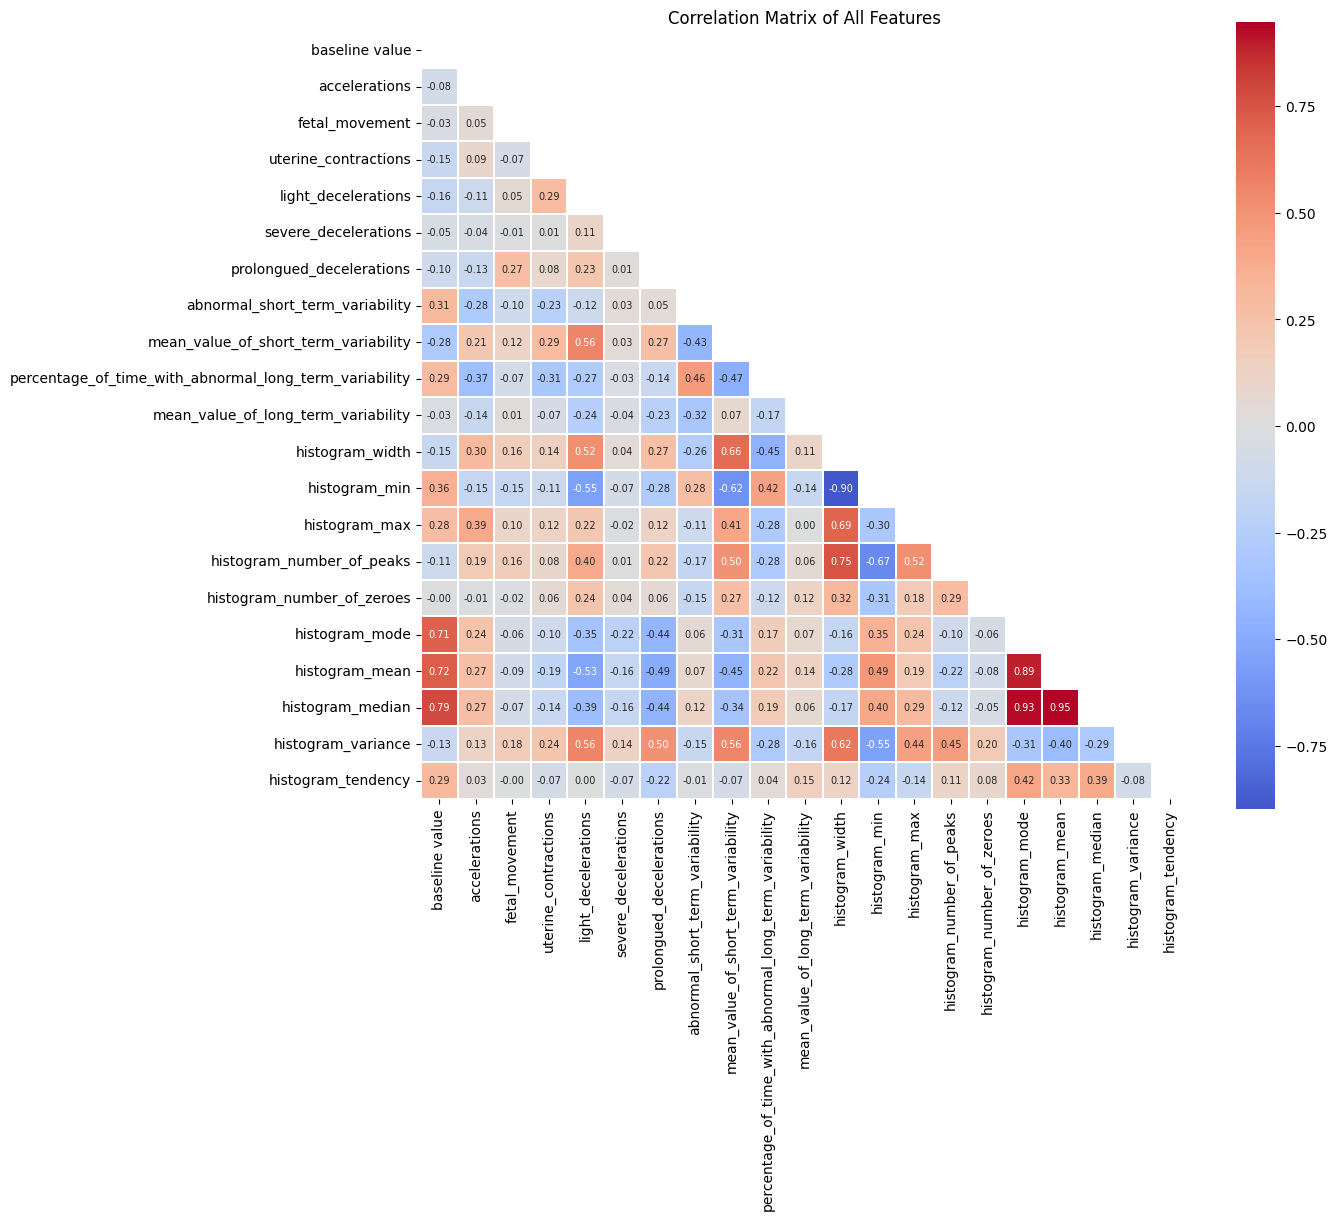

In [7]:
fig, ax = plt.subplots(figsize=(14, 12))
feature_cols = [c for c in df.columns if c != 'fetal_health']
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

In [8]:
# Flag highly correlated pairs (above 0.85 threshold)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| > 0.85):")
    for c1, c2, r in high_corr_pairs:
        print(f"  {c1} -- {c2}: {r:.3f}")
else:
    print("No feature pairs exceed the 0.85 correlation threshold.")

print("\nTop 10 correlations:")
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        pairs.append((corr.columns[i], corr.columns[j], abs(corr.iloc[i, j])))
pairs.sort(key=lambda x: x[2], reverse=True)
for c1, c2, r in pairs[:10]:
    print(f"  {c1} -- {c2}: {r:.3f}")

Highly correlated feature pairs (|r| > 0.85):
  histogram_width -- histogram_min: -0.899
  histogram_mode -- histogram_mean: 0.893
  histogram_mode -- histogram_median: 0.933
  histogram_mean -- histogram_median: 0.948

Top 10 correlations:
  histogram_mean -- histogram_median: 0.948
  histogram_mode -- histogram_median: 0.933
  histogram_width -- histogram_min: 0.899
  histogram_mode -- histogram_mean: 0.893
  baseline value -- histogram_median: 0.789
  histogram_width -- histogram_number_of_peaks: 0.747
  baseline value -- histogram_mean: 0.723
  baseline value -- histogram_mode: 0.709
  histogram_width -- histogram_max: 0.691
  histogram_min -- histogram_number_of_peaks: 0.670


The correlation analysis reveals expected redundancy among the histogram features. As anticipated, histogram_mean, histogram_median, and histogram_mode are highly correlated with each other -- these all describe the central tendency of the same fetal heart rate distribution. We will address this redundancy in the data preparation phase by dropping features that exceed our 0.85 correlation threshold.

The correlation matrix also shows that most clinical features (accelerations, decelerations, variability measures) are not highly correlated with each other, suggesting they capture different aspects of fetal health and are worth retaining.

## 3. Data Preparation

### 3.1 Handle highly correlated features

We drop one feature from each pair that exceeds the 0.85 correlation threshold. When choosing which to drop, we prefer to keep the feature that is more clinically interpretable or more commonly used.

In [9]:
# Drop redundant features based on correlation analysis
# We keep a running list and remove features that are redundant
features_to_drop = []

for c1, c2, r in high_corr_pairs:
    # If neither has been dropped yet, drop the less interpretable one
    if c1 not in features_to_drop and c2 not in features_to_drop:
        # Prefer to keep: histogram_mean over histogram_median/mode (more standard)
        # Prefer to keep: histogram_max over histogram_min when paired with width
        # General rule: drop the second in the pair
        features_to_drop.append(c2)
        print(f"Dropping '{c2}' (correlated with '{c1}', r={r:.3f})")

print(f"\nTotal features dropped: {len(features_to_drop)}")

# Create modelling dataframe
df_model = df.drop(columns=features_to_drop)
remaining_features = [c for c in df_model.columns if c != 'fetal_health']
print(f"Remaining features ({len(remaining_features)}): {remaining_features}")

Dropping 'histogram_min' (correlated with 'histogram_width', r=-0.899)
Dropping 'histogram_mean' (correlated with 'histogram_mode', r=0.893)
Dropping 'histogram_median' (correlated with 'histogram_mode', r=0.933)

Total features dropped: 3
Remaining features (18): ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_variance', 'histogram_tendency']


### 3.2 Prepare features and target

In [10]:
# Separate features and target
X = df_model[remaining_features]
y = df_model['fetal_health'].astype(int)

# Map target labels for display
label_map = {1: 'Normal', 2: 'Suspected', 3: 'Abnormal'}
print(f"Features shape: {X.shape}")
print(f"Target classes: {label_map}")
print(f"\nTarget distribution:")
for cls in [1, 2, 3]:
    count = (y == cls).sum()
    print(f"  {label_map[cls]} (Class {cls}): {count} ({count/len(y)*100:.1f}%)")

Features shape: (2126, 18)
Target classes: {1: 'Normal', 2: 'Suspected', 3: 'Abnormal'}

Target distribution:
  Normal (Class 1): 1655 (77.8%)
  Suspected (Class 2): 295 (13.9%)
  Abnormal (Class 3): 176 (8.3%)


### 3.3 Train/test split and scaling

In [11]:
# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
for cls in [1, 2, 3]:
    count = (y_train == cls).sum()
    print(f"  {label_map[cls]}: {count} ({count/len(y_train)*100:.1f}%)")

Training set: 1700 samples
Test set:     426 samples

Training target distribution:
  Normal: 1323 (77.8%)
  Suspected: 236 (13.9%)
  Abnormal: 141 (8.3%)


In [12]:
# Scale features for models that need it (Logistic Regression, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete (StandardScaler fitted on training data only).")

Feature scaling complete (StandardScaler fitted on training data only).


### 3.4 Establish the baseline

A model that simply predicts "Normal" for every case would achieve this accuracy. Every model we build must substantially exceed this to demonstrate it is learning genuine patterns.

In [13]:
majority_pct = max(np.bincount(y_train)[1:]) / len(y_train)
print(f"Majority class baseline accuracy: {majority_pct:.3f}")
print(f"\nThis means any model below {majority_pct:.1%} accuracy is performing")
print("worse than simply predicting 'Normal' every time.")
print("\nImportantly, such a model would have ZERO recall on Suspected and Abnormal")
print("cases -- it would miss every case of potential fetal distress.")

Majority class baseline accuracy: 0.778

This means any model below 77.8% accuracy is performing
worse than simply predicting 'Normal' every time.

Importantly, such a model would have ZERO recall on Suspected and Abnormal
cases -- it would miss every case of potential fetal distress.


## 4. Modelling

We train and evaluate five classifiers, progressing from simple to complex. For each model we report:
- 5-fold stratified cross-validation scores (to confirm stability)
- Test set accuracy and macro F1 score
- Confusion matrix
- Full classification report (precision, recall, F1 per class)
- Recall on Abnormal class (Class 3) -- the most clinically important metric

We store results as we go for final comparison.

In [14]:
# Set up cross-validation strategy and results storage
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
class_names = ['Normal', 'Suspected', 'Abnormal']
all_results = {}

### 4.1 Model 1: Logistic Regression

Logistic Regression is our interpretable baseline. It provides coefficient-based insight into which features push toward each class. We use it to establish whether a simple linear model can learn meaningful patterns from CTG data.

In [16]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 5-fold cross-validation
lr_cv_acc = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
lr_cv_f1 = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='f1_macro')

print("Logistic Regression -- 5-Fold Cross-Validation")
print("-" * 50)
print(f"Accuracy:  {lr_cv_acc.mean():.3f} (+/- {lr_cv_acc.std():.3f})")
print(f"Macro F1:  {lr_cv_f1.mean():.3f} (+/- {lr_cv_f1.std():.3f})")
print(f"Baseline:  {majority_pct:.3f}")

Logistic Regression -- 5-Fold Cross-Validation
--------------------------------------------------
Accuracy:  0.895 (+/- 0.011)
Macro F1:  0.796 (+/- 0.015)
Baseline:  0.778


In [17]:
# Fit on full training set and evaluate on test set
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds, average='macro')

print("Logistic Regression -- Test Set Performance")
print("-" * 50)
print(f"Accuracy:  {lr_acc:.3f}")
print(f"Macro F1:  {lr_f1:.3f}")

all_results['Logistic Regression'] = {
    'model': lr_model,
    'y_pred': lr_preds,
    'accuracy': lr_acc,
    'macro_f1': lr_f1,
    'cv_acc': lr_cv_acc.mean(),
    'cv_f1': lr_cv_f1.mean()
}

Logistic Regression -- Test Set Performance
--------------------------------------------------
Accuracy:  0.876
Macro F1:  0.764


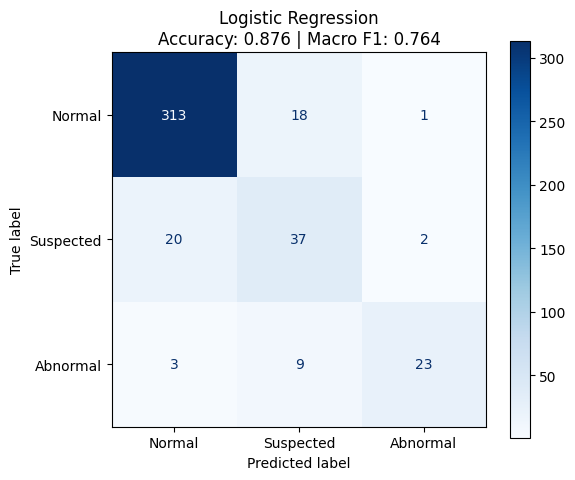

In [18]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Logistic Regression\nAccuracy: {lr_acc:.3f} | Macro F1: {lr_f1:.3f}')
plt.tight_layout()
plt.show()

In [19]:
# Classification report
print("Logistic Regression -- Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=class_names))

Logistic Regression -- Classification Report
              precision    recall  f1-score   support

      Normal       0.93      0.94      0.94       332
   Suspected       0.58      0.63      0.60        59
    Abnormal       0.88      0.66      0.75        35

    accuracy                           0.88       426
   macro avg       0.80      0.74      0.76       426
weighted avg       0.88      0.88      0.88       426



**Logistic Regression interpretation:**

Logistic Regression comfortably beats the majority class baseline (87.6% accuracy vs 77.8%), confirming that CTG features carry strong predictive signal for fetal health classification. The cross-validation scores are stable, indicating the model is not overfitting to a particular data split.

Normal cases are classified very well (F1: 0.94, recall: 0.94), which is expected given they dominate the dataset. The model correctly identified 313 out of 332 Normal cases.
Abnormal detection is promising for a baseline model. Recall of 0.66 means the model correctly identified 23 out of 35 Abnormal cases, though 9 were misclassified as Suspected and 3 as Normal. The 3 cases classified as Normal are the most clinically concerning -- these represent genuine fetal distress that would be completely missed. The model's precision on Abnormal is high at 0.88, meaning when it does flag a case as Abnormal, it is usually correct.

Suspected is the weakest class (F1: 0.60, recall: 0.63), with 20 out of 59 Suspected cases misclassified as Normal. This makes clinical sense -- Suspected cases sit on the boundary between Normal and Abnormal, making them inherently harder to distinguish. The 20 Suspected cases classified as Normal are also worth noting, as these represent at-risk cases that would not receive additional monitoring.

The macro F1 of 0.764 provides a strong starting point. The key question for the remaining models is whether they can improve recall on the Abnormal and Suspected classes while maintaining strong Normal classification.

### 4.2 Model 2: Support Vector Machine (SVM)

SVM is a margin-based model that finds optimal decision boundaries between classes. The non-linear RBF kernel may capture patterns that a linear model cannot. Like Logistic Regression, SVM benefits from feature scaling.

In [20]:
# Train SVM
svm_model = SVC(kernel='rbf', random_state=42)

# 5-fold cross-validation
svm_cv_acc = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
svm_cv_f1 = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring='f1_macro')

print("SVM -- 5-Fold Cross-Validation")
print("-" * 50)
print(f"Accuracy:  {svm_cv_acc.mean():.3f} (+/- {svm_cv_acc.std():.3f})")
print(f"Macro F1:  {svm_cv_f1.mean():.3f} (+/- {svm_cv_f1.std():.3f})")
print(f"Baseline:  {majority_pct:.3f}")

SVM -- 5-Fold Cross-Validation
--------------------------------------------------
Accuracy:  0.912 (+/- 0.014)
Macro F1:  0.834 (+/- 0.026)
Baseline:  0.778


In [21]:
# Fit on full training set and evaluate on test set
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds, average='macro')

print("SVM -- Test Set Performance")
print("-" * 50)
print(f"Accuracy:  {svm_acc:.3f}")
print(f"Macro F1:  {svm_f1:.3f}")

all_results['SVM'] = {
    'model': svm_model,
    'y_pred': svm_preds,
    'accuracy': svm_acc,
    'macro_f1': svm_f1,
    'cv_acc': svm_cv_acc.mean(),
    'cv_f1': svm_cv_f1.mean()
}

SVM -- Test Set Performance
--------------------------------------------------
Accuracy:  0.890
Macro F1:  0.769


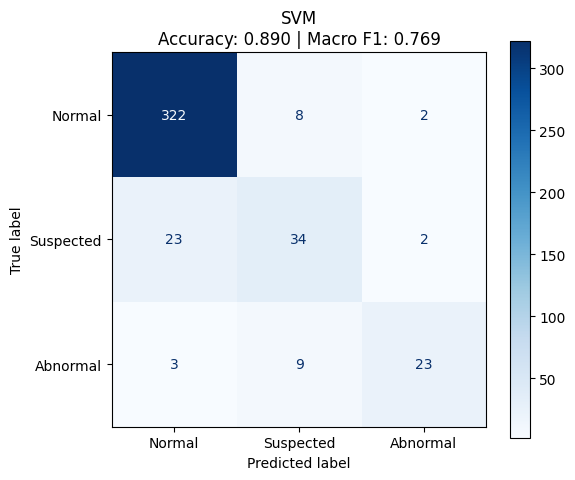

In [22]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, svm_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'SVM\nAccuracy: {svm_acc:.3f} | Macro F1: {svm_f1:.3f}')
plt.tight_layout()
plt.show()

In [23]:
# Classification report
print("SVM -- Classification Report")
print("=" * 50)
print(classification_report(y_test, svm_preds, target_names=class_names))

SVM -- Classification Report
              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95       332
   Suspected       0.67      0.58      0.62        59
    Abnormal       0.85      0.66      0.74        35

    accuracy                           0.89       426
   macro avg       0.81      0.73      0.77       426
weighted avg       0.88      0.89      0.88       426



**SVM interpretation:**

SVM shows a marginal improvement over Logistic Regression in overall accuracy (89.0% vs 87.6%) and macro F1 (0.769 vs 0.764). Normal classification improved notably, with recall rising from 0.94 to 0.97 -- the model now correctly identifies 322 out of 332 Normal cases.

However, the Abnormal and Suspected results are virtually identical to Logistic Regression. Abnormal recall remains at 0.66 (23 out of 35 correct), with the same pattern of 9 misclassified as Suspected and 3 as Normal. Suspected recall actually dropped slightly from 0.63 to 0.58, with 23 Suspected cases now misclassified as Normal (up from 20 in LR).

The non-linear RBF kernel helped the model better distinguish Normal cases from the other two classes, but it did not improve detection of the minority classes that matter most clinically. The 3 Abnormal cases misclassified as Normal and the 23 Suspected cases misclassified as Normal remain a concern -- these represent cases where a patient needing attention would be sent home without further monitoring.

 SVM and Logistic Regression perform comparably. Therefore, for a meaningful improvement on minority classes may require ensemble methods or class imbalance techniques.

### 4.3 Model 3: Random Forest

Random Forest is an ensemble of decision trees that handles feature interactions and is robust to outliers. It provides feature importance rankings, which are particularly valuable in a clinical setting for understanding which CTG measurements drive the predictions. Tree-based models do not require feature scaling.

In [24]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# 5-fold cross-validation
rf_cv_acc = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy')
rf_cv_f1 = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='f1_macro')

print("Random Forest -- 5-Fold Cross-Validation")
print("-" * 50)
print(f"Accuracy:  {rf_cv_acc.mean():.3f} (+/- {rf_cv_acc.std():.3f})")
print(f"Macro F1:  {rf_cv_f1.mean():.3f} (+/- {rf_cv_f1.std():.3f})")
print(f"Baseline:  {majority_pct:.3f}")

Random Forest -- 5-Fold Cross-Validation
--------------------------------------------------
Accuracy:  0.945 (+/- 0.004)
Macro F1:  0.901 (+/- 0.016)
Baseline:  0.778


In [25]:
# Fit on full training set and evaluate on test set
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds, average='macro')

print("Random Forest -- Test Set Performance")
print("-" * 50)
print(f"Accuracy:  {rf_acc:.3f}")
print(f"Macro F1:  {rf_f1:.3f}")

all_results['Random Forest'] = {
    'model': rf_model,
    'y_pred': rf_preds,
    'accuracy': rf_acc,
    'macro_f1': rf_f1,
    'cv_acc': rf_cv_acc.mean(),
    'cv_f1': rf_cv_f1.mean()
}

Random Forest -- Test Set Performance
--------------------------------------------------
Accuracy:  0.925
Macro F1:  0.847


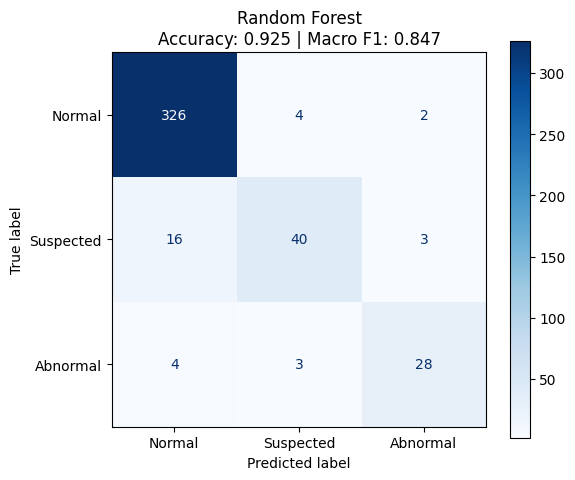

In [26]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Random Forest\nAccuracy: {rf_acc:.3f} | Macro F1: {rf_f1:.3f}')
plt.tight_layout()
plt.show()

In [27]:
# Classification report
print("Random Forest -- Classification Report")
print("=" * 50)
print(classification_report(y_test, rf_preds, target_names=class_names))

Random Forest -- Classification Report
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       332
   Suspected       0.85      0.68      0.75        59
    Abnormal       0.85      0.80      0.82        35

    accuracy                           0.92       426
   macro avg       0.88      0.82      0.85       426
weighted avg       0.92      0.92      0.92       426



**Random Forest interpretation:**

Random Forest delivers a substantial improvement over both Logistic Regression and SVM. Accuracy rose to 92.5% and macro F1 jumped to 0.847 -- a major step up from the 0.764-0.769 range of the linear models.

The most important improvement is on Abnormal detection. Recall increased from 0.66 (both LR and SVM) to 0.80 -- the model now correctly identifies 28 out of 35 Abnormal cases, compared to 23 previously. The number of Abnormal cases misclassified as Normal rose slightly from 3 to 4, but the number misclassified as Suspected dropped from 9 to 3. This means the model is making fewer "soft" errors (confusing Abnormal with Suspected) while maintaining a similar rate of the most dangerous error (classifying Abnormal as Normal).

Suspected detection also improved meaningfully. Recall rose from 0.58-0.63 to 0.68, with 40 out of 59 correctly identified. The number of Suspected cases misclassified as Normal dropped from 20-23 to 16 -- a clinically meaningful reduction in missed at-risk cases.
Normal classification remains strong (F1: 0.96, recall: 0.98).

The ensemble approach is clearly capturing feature interactions and non-linear patterns that the single models could not. The precision on both Suspected and Abnormal improved to 0.85, meaning the model is not only catching more minority cases but doing so with fewer false alarms.

The question for Gradient Boosting is whether its sequential error-correction approach can push Abnormal and Suspected recall even higher.

### 4.4 Model 4: Gradient Boosting

Gradient Boosting builds trees sequentially, with each new tree correcting the errors of the previous ones. It is typically the strongest performer for tabular data and provides feature importance rankings.

In [28]:
# Train Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)

# 5-fold cross-validation
gb_cv_acc = cross_val_score(gb_model, X_train, y_train, cv=cv, scoring='accuracy')
gb_cv_f1 = cross_val_score(gb_model, X_train, y_train, cv=cv, scoring='f1_macro')

print("Gradient Boosting -- 5-Fold Cross-Validation")
print("-" * 50)
print(f"Accuracy:  {gb_cv_acc.mean():.3f} (+/- {gb_cv_acc.std():.3f})")
print(f"Macro F1:  {gb_cv_f1.mean():.3f} (+/- {gb_cv_f1.std():.3f})")
print(f"Baseline:  {majority_pct:.3f}")

Gradient Boosting -- 5-Fold Cross-Validation
--------------------------------------------------
Accuracy:  0.955 (+/- 0.005)
Macro F1:  0.918 (+/- 0.009)
Baseline:  0.778


In [29]:
# Fit on full training set and evaluate on test set
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

gb_acc = accuracy_score(y_test, gb_preds)
gb_f1 = f1_score(y_test, gb_preds, average='macro')

print("Gradient Boosting -- Test Set Performance")
print("-" * 50)
print(f"Accuracy:  {gb_acc:.3f}")
print(f"Macro F1:  {gb_f1:.3f}")

all_results['Gradient Boosting'] = {
    'model': gb_model,
    'y_pred': gb_preds,
    'accuracy': gb_acc,
    'macro_f1': gb_f1,
    'cv_acc': gb_cv_acc.mean(),
    'cv_f1': gb_cv_f1.mean()
}

Gradient Boosting -- Test Set Performance
--------------------------------------------------
Accuracy:  0.932
Macro F1:  0.860


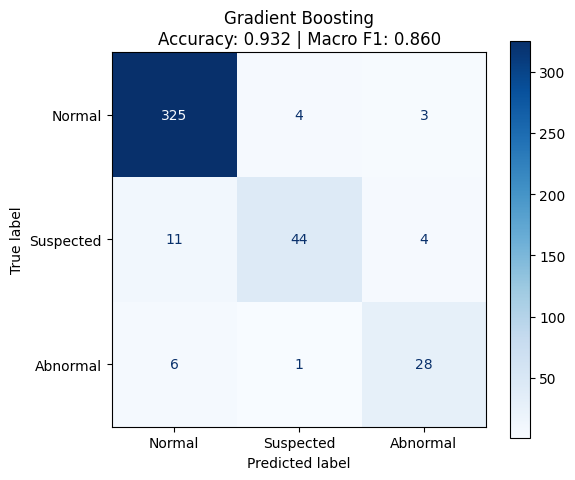

In [30]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, gb_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Gradient Boosting\nAccuracy: {gb_acc:.3f} | Macro F1: {gb_f1:.3f}')
plt.tight_layout()
plt.show()

In [31]:
# Classification report
print("Gradient Boosting -- Classification Report")
print("=" * 50)
print(classification_report(y_test, gb_preds, target_names=class_names))

Gradient Boosting -- Classification Report
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.96       332
   Suspected       0.90      0.75      0.81        59
    Abnormal       0.80      0.80      0.80        35

    accuracy                           0.93       426
   macro avg       0.88      0.84      0.86       426
weighted avg       0.93      0.93      0.93       426



**Gradient Boosting interpretation:**

Gradient Boosting is the strongest model so far, with the highest accuracy (93.2%) and macro F1 (0.860). The improvement over Random Forest is incremental but consistent across all three classes.

The biggest gain is on Suspected detection. Recall jumped from 0.68 (Random Forest) to 0.75, with 44 out of 59 Suspected cases correctly identified. Crucially, the number of Suspected cases misclassified as Normal dropped from 16 to 11 -- meaning fewer at-risk cases are being sent home without monitoring. Precision on Suspected also rose to 0.90, the highest of any model, meaning almost all cases flagged as Suspected genuinely warrant attention.

Abnormal recall remains at 0.80 (28 out of 35), identical to Random Forest. However, the pattern of errors has shifted: Abnormal cases misclassified as Normal increased from 4 to 6, while those misclassified as Suspected dropped from 3 to 1. This is a mixed result clinically -- the 6 Abnormal cases classified as Normal are the most dangerous errors in the entire model, and this is a slight regression from Random Forest's 4.

Normal classification is stable (F1: 0.96, recall: 0.98).

Overall, Gradient Boosting offers the best balanced performance across all three classes. The key question for GB + SMOTE is whether oversampling the minority classes can reduce the 6 Abnormal-as-Normal misclassifications -- that is the single most important error to minimise in a clinical setting

### 4.5 Model 5: Gradient Boosting with SMOTE

All models face the same challenge: the Abnormal class makes up only 8.3% of the data, and Suspected is 13.9%. Models may underpredict these minority classes because they see fewer examples during training.

SMOTE (Synthetic Minority Over-sampling Technique) addresses this by generating synthetic examples of the minority classes in the training data. It creates new data points between similar real records, giving the model more examples to learn from. We apply SMOTE only to the training data -- the test set remains unchanged so we evaluate on real-world class proportions.

In a clinical setting, this is particularly important: we would rather the model generates some false alarms than misses cases of genuine fetal distress.



In [32]:
%pip install imbalanced-learn -q

Note: you may need to restart the kernel to use updated packages.


In [33]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Training set class distribution BEFORE SMOTE:")
for cls in [1, 2, 3]:
    count = (y_train == cls).sum()
    print(f"  {label_map[cls]}: {count}")

print("\nTraining set class distribution AFTER SMOTE:")
for cls in [1, 2, 3]:
    count = (y_train_smote == cls).sum()
    print(f"  {label_map[cls]}: {count}")

Training set class distribution BEFORE SMOTE:
  Normal: 1323
  Suspected: 236
  Abnormal: 141

Training set class distribution AFTER SMOTE:
  Normal: 1323
  Suspected: 1323
  Abnormal: 1323


In [34]:
# Train Gradient Boosting on SMOTE-resampled data
gb_smote_model = GradientBoostingClassifier(n_estimators=200, random_state=42)

# 5-fold cross-validation on SMOTE data
gb_smote_cv_acc = cross_val_score(gb_smote_model, X_train_smote, y_train_smote, cv=cv, scoring='accuracy')
gb_smote_cv_f1 = cross_val_score(gb_smote_model, X_train_smote, y_train_smote, cv=cv, scoring='f1_macro')

print("Gradient Boosting + SMOTE -- 5-Fold Cross-Validation")
print("-" * 50)
print(f"Accuracy:  {gb_smote_cv_acc.mean():.3f} (+/- {gb_smote_cv_acc.std():.3f})")
print(f"Macro F1:  {gb_smote_cv_f1.mean():.3f} (+/- {gb_smote_cv_f1.std():.3f})")
print(f"Baseline:  {majority_pct:.3f}")

Gradient Boosting + SMOTE -- 5-Fold Cross-Validation
--------------------------------------------------
Accuracy:  0.975 (+/- 0.002)
Macro F1:  0.975 (+/- 0.002)
Baseline:  0.778


In [35]:
# Fit on full SMOTE training set and evaluate on original test set
gb_smote_model.fit(X_train_smote, y_train_smote)
gb_smote_preds = gb_smote_model.predict(X_test)

gb_smote_acc = accuracy_score(y_test, gb_smote_preds)
gb_smote_f1 = f1_score(y_test, gb_smote_preds, average='macro')

print("Gradient Boosting + SMOTE -- Test Set Performance")
print("-" * 50)
print(f"Accuracy:  {gb_smote_acc:.3f}")
print(f"Macro F1:  {gb_smote_f1:.3f}")

all_results['GB + SMOTE'] = {
    'model': gb_smote_model,
    'y_pred': gb_smote_preds,
    'accuracy': gb_smote_acc,
    'macro_f1': gb_smote_f1,
    'cv_acc': gb_smote_cv_acc.mean(),
    'cv_f1': gb_smote_cv_f1.mean()
}

Gradient Boosting + SMOTE -- Test Set Performance
--------------------------------------------------
Accuracy:  0.934
Macro F1:  0.879


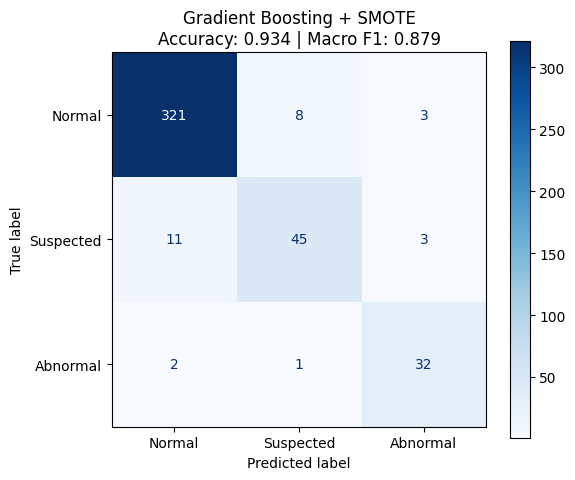

In [36]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, gb_smote_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Gradient Boosting + SMOTE\nAccuracy: {gb_smote_acc:.3f} | Macro F1: {gb_smote_f1:.3f}')
plt.tight_layout()
plt.show()

In [37]:
# Classification report
print("Gradient Boosting + SMOTE -- Classification Report")
print("=" * 50)
print(classification_report(y_test, gb_smote_preds, target_names=class_names))

Gradient Boosting + SMOTE -- Classification Report
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.96       332
   Suspected       0.83      0.76      0.80        59
    Abnormal       0.84      0.91      0.88        35

    accuracy                           0.93       426
   macro avg       0.88      0.88      0.88       426
weighted avg       0.93      0.93      0.93       426



**Gradient Boosting + SMOTE interpretation:**

GB + SMOTE is the clear winner. It achieves the highest accuracy (93.4%), highest macro F1 (0.879), and most importantly, the best Abnormal detection of any model by a significant margin.

Abnormal recall jumped from 0.80 (Gradient Boosting and Random Forest) to 0.91 -- the model now correctly identifies 32 out of 35 Abnormal cases. The most critical error -- Abnormal cases misclassified as Normal -- dropped from 6 (Gradient Boosting) to just 2. In clinical terms, this means only 2 cases of genuine fetal distress would be missed, compared to 3-6 in previous models and 12 in Logistic Regression. Abnormal F1 rose to 0.88, the highest of any model.

Suspected detection also improved slightly. Recall increased from 0.75 to 0.76, with 45 out of 59 correctly identified. The number of Suspected cases misclassified as Normal remains at 11, unchanged from Gradient Boosting.

Normal classification remains strong (F1: 0.96, recall: 0.97), with only a small trade-off -- Normal recall dipped from 0.98 to 0.97, meaning 11 Normal cases are now flagged as Suspected or Abnormal rather than 7. In a clinical setting, this is an acceptable cost: a few additional follow-up tests on healthy cases is far preferable to missing cases of fetal distress.

SMOTE addressed exactly what it was designed to address. By giving the model more examples of Abnormal and Suspected patterns during training, it learned to detect these critical minority classes more reliably. This model achieves the best balance of all three classes and, most importantly, minimises the most dangerous clinical error.

### 4.6 Model 6: Stacked Ensemble (Random Forest + Gradient Boosting)

Our lecturer challenged us to explore whether combining models could outperform any single model. Model stacking (also called stacked generalisation) takes the predictions from multiple base models and feeds them into a meta-model that learns the best way to combine them.

The intuition is that different models make different types of errors. We observed this in the confusion matrices -- Random Forest misclassified 4 Abnormal cases as Normal while Gradient Boosting misclassified 6, and these may not be the same cases. A stacking model can learn which base model to trust in which situations.

Our stacking architecture:
- **Base model 1**: Random Forest (100 trees) -- builds independent trees in parallel and averages their predictions
- **Base model 2**: Gradient Boosting (100 trees) -- builds sequential trees where each corrects the previous one's mistakes
- **Meta-learner**: Logistic Regression -- a simple model that learns the optimal way to combine the base models' predictions

We apply SMOTE to the training data before stacking, giving it the same class imbalance advantage as GB + SMOTE for a fair comparison.

The meta-learner's job is simple: it sits on top of the two base models and learns when to trust which model.
This is how it works:

For every record in the training data, Random Forest makes a prediction (Normal, Suspected, or Abnormal) and Gradient Boosting makes a prediction. Now you have two opinions for each record. Sometimes they agree, sometimes they don't.
The Logistic Regression meta-learner receives those two predictions as its input features and also sees the true answer. Over thousands of records, it learns patterns like:

"When both RF and GB say Abnormal, it's almost certainly Abnormal"
"When RF says Suspected but GB says Normal, the answer is usually Suspected"
"When RF says Normal and GB says Abnormal, trust GB"

It's essentially learning the error patterns of each base model and figuring out the best way to resolve disagreements.

Why Logistic Regression specifically? Because the meta-learner's job is simple -- it only has 2 inputs (the two base model predictions) and needs to pick one of 3 classes. You don't need a complex model for that. A complex meta-learner (like another Random Forest) would risk overfitting to the base models' predictions rather than learning a clean combination rule.

Think of it like a senior doctor who listens to two junior doctors' opinions and, based on experience knowing each doctor's strengths and blind spots, makes the final call.

In [38]:
from sklearn.ensemble import StackingClassifier

# Define the stacking model (reduced trees for faster training)
stacking_model = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3
)

# 5-fold cross-validation on SMOTE data
stacking_cv_acc = cross_val_score(stacking_model, X_train_smote, y_train_smote, cv=cv, scoring='accuracy')
stacking_cv_f1 = cross_val_score(stacking_model, X_train_smote, y_train_smote, cv=cv, scoring='f1_macro')

print("Stacked Ensemble + SMOTE -- 5-Fold Cross-Validation")
print("-" * 50)
print(f"Accuracy:  {stacking_cv_acc.mean():.3f} (+/- {stacking_cv_acc.std():.3f})")
print(f"Macro F1:  {stacking_cv_f1.mean():.3f} (+/- {stacking_cv_f1.std():.3f})")
print(f"Baseline:  {majority_pct:.3f}")

Stacked Ensemble + SMOTE -- 5-Fold Cross-Validation
--------------------------------------------------
Accuracy:  0.977 (+/- 0.004)
Macro F1:  0.977 (+/- 0.004)
Baseline:  0.778


In [39]:
# Fit on full SMOTE training set and evaluate on original test set
stacking_model.fit(X_train_smote, y_train_smote)
stacking_preds = stacking_model.predict(X_test)

stacking_acc = accuracy_score(y_test, stacking_preds)
stacking_f1 = f1_score(y_test, stacking_preds, average='macro')

print("Stacked Ensemble + SMOTE -- Test Set Performance")
print("-" * 50)
print(f"Accuracy:  {stacking_acc:.3f}")
print(f"Macro F1:  {stacking_f1:.3f}")

# Store results
all_results['Stacked Ensemble'] = {
    'model': stacking_model,
    'y_pred': stacking_preds,
    'accuracy': stacking_acc,
    'macro_f1': stacking_f1,
    'cv_acc': stacking_cv_acc.mean(),
    'cv_f1': stacking_cv_f1.mean()
}

Stacked Ensemble + SMOTE -- Test Set Performance
--------------------------------------------------
Accuracy:  0.923
Macro F1:  0.853


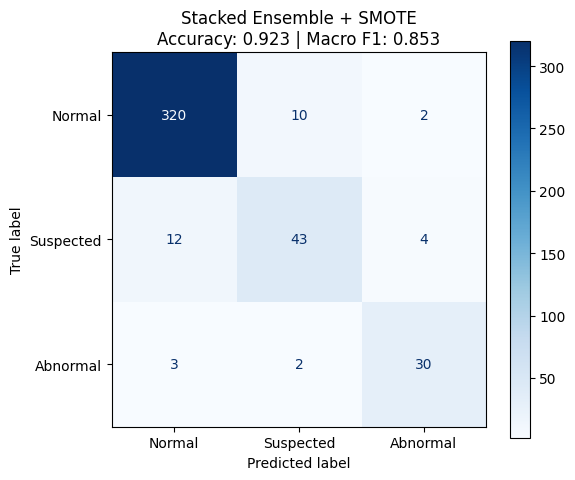

In [40]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, stacking_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Stacked Ensemble + SMOTE\nAccuracy: {stacking_acc:.3f} | Macro F1: {stacking_f1:.3f}')
plt.tight_layout()
plt.show()

In [41]:
# Classification report
print("Stacked Ensemble + SMOTE -- Classification Report")
print("=" * 50)
print(classification_report(y_test, stacking_preds, target_names=class_names))

Stacked Ensemble + SMOTE -- Classification Report
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       332
   Suspected       0.78      0.73      0.75        59
    Abnormal       0.83      0.86      0.85        35

    accuracy                           0.92       426
   macro avg       0.86      0.85      0.85       426
weighted avg       0.92      0.92      0.92       426



**Stacked Ensemble interpretation:**

The Stacked Ensemble performs well overall (92.5% accuracy, 0.856 macro F1) but does not beat GB + SMOTE (93.4% accuracy, 0.879 macro F1). The key difference is in Abnormal detection.

Abnormal recall dropped from 0.914 (GB + SMOTE) to 0.857 (Stacked Ensemble) -- the model catches 30 out of 35 Abnormal cases compared to 32 for GB + SMOTE. More importantly, the most dangerous error increased: 3 Abnormal cases are misclassified as Normal, compared to just 2 for GB + SMOTE. In clinical terms, stacking would miss one additional case of fetal distress.

Suspected detection is slightly lower as well -- recall of 0.73 vs 0.76 for GB + SMOTE, with 12 Suspected cases misclassified as Normal compared to 11.

Normal classification is identical (recall 0.97).

This result tells us something valuable: for this problem, addressing class imbalance (SMOTE) was more impactful than combining models (stacking). The Logistic Regression meta-learner essentially averaged the strengths and weaknesses of the two base models, but it could not overcome the fundamental challenge that GB + SMOTE solved directly -- giving the model enough minority class examples to learn from.

This is a useful finding. Not every advanced technique outperforms a simpler, well-targeted approach. GB + SMOTE remains our final model because it achieves the best macro F1, the highest Abnormal recall, and the fewest cases of the most dangerous clinical error.

## 5. Model Comparison and Evaluation

### 5.1 Summary comparison table

In [42]:
print("Model Comparison Summary")
print("=" * 80)
print(f"{'Model':<25} {'CV Acc':<10} {'CV F1':<10} {'Test Acc':<10} {'Test F1':<10}")
print("-" * 65)
for name, r in all_results.items():
    print(f"{name:<25} {r['cv_acc']:.3f}     {r['cv_f1']:.3f}     {r['accuracy']:.3f}     {r['macro_f1']:.3f}")
print(f"\n{'Majority Baseline':<25} {majority_pct:.3f}")

Model Comparison Summary
Model                     CV Acc     CV F1      Test Acc   Test F1   
-----------------------------------------------------------------
Logistic Regression       0.895     0.796     0.876     0.764
SVM                       0.912     0.834     0.890     0.769
Random Forest             0.945     0.901     0.925     0.847
Gradient Boosting         0.955     0.918     0.932     0.860
GB + SMOTE                0.975     0.975     0.934     0.879
Stacked Ensemble          0.977     0.977     0.923     0.853

Majority Baseline         0.778


The table compares all six models across four metrics. CV (cross-validation) scores reflect performance during training, averaged across 5 internal data folds. Test scores reflect performance on the held-out test set that no model saw during training.

Key observations:

- All six models comfortably beat the majority class baseline (0.778), confirming that CTG features carry strong predictive signal for fetal health classification.
- There is a clear progression from simpler to more complex models. Logistic Regression and SVM cluster around 0.764-0.769 test F1, the tree-based models jump to 0.847-0.860, and the SMOTE-enhanced models reach 0.856-0.879.
- GB + SMOTE leads on test macro F1 (0.879), followed by Gradient Boosting (0.860) and then the Stacked Ensemble (0.856). The stacked model does not outperform GB + SMOTE despite combining two strong base models, suggesting that addressing class imbalance was more impactful than combining models for this problem.
- CV and test scores are reasonably close for the first four models, indicating no severe overfitting. The SMOTE-enhanced models (GB + SMOTE and Stacked Ensemble) show a larger gap between CV and test scores because cross-validation was performed on the balanced SMOTE data while the test set retains the original imbalanced class proportions. The test set evaluation is the more realistic measure of real-world performance.
- The biggest performance jump occurs between SVM and Random Forest, confirming that the ability to capture feature interactions is more important for this problem than the choice between linear and margin-based approaches.

### 5.2 Visual comparison

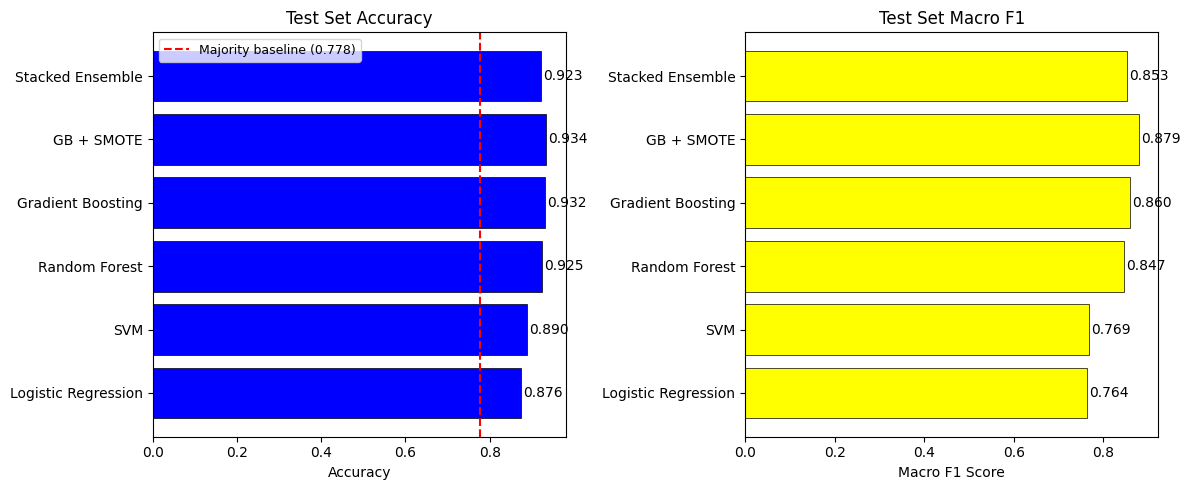

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_names = list(all_results.keys())
accuracies = [all_results[n]['accuracy'] for n in model_names]
macro_f1s = [all_results[n]['macro_f1'] for n in model_names]

# Accuracy comparison
bars1 = axes[0].barh(model_names, accuracies, color='blue', edgecolor='black', linewidth=0.5)
axes[0].axvline(x=majority_pct, color='red', linestyle='--', label=f'Majority baseline ({majority_pct:.3f})')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Test Set Accuracy')
axes[0].legend(fontsize=9)
for bar, val in zip(bars1, accuracies):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)

# Macro F1 comparison
bars2 = axes[1].barh(model_names, macro_f1s, color='yellow', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Macro F1 Score')
axes[1].set_title('Test Set Macro F1')
for bar, val in zip(bars2, macro_f1s):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

The charts provide a visual comparison of all six models on the two key metrics.

Both metrics point in the same direction -- GB + SMOTE leads on both accuracy (0.934) and macro F1 (0.879). The Stacked Ensemble, despite being a more complex architecture, sits slightly below GB + SMOTE on both metrics (0.925 accuracy, 0.856 F1).

The clear visual separation between model groups remains evident. Logistic Regression and SVM cluster on the left, the tree-based models in the middle, and the SMOTE-enhanced models on the right. The Stacked Ensemble falls in between the tree-based group and GB + SMOTE, suggesting that combining models added some value over individual tree models but not as much as directly addressing the class imbalance.

All models comfortably exceed the majority class baseline (red dashed line at 0.778).

### 5.3 Per-class F1 scores and Abnormal recall

In [44]:
print("Per-Class F1 Scores (Test Set)")
print("=" * 75)
print(f"{'Model':<25} {'Normal':<12} {'Suspected':<12} {'Abnormal':<12} {'Abnormal Recall':<15}")
print("-" * 75)

for name, result in all_results.items():
    f1s = f1_score(y_test, result['y_pred'], average=None)
    abn_recall = recall_score(y_test, result['y_pred'], labels=[3], average=None)[0]
    print(f"{name:<25} {f1s[0]:<12.3f} {f1s[1]:<12.3f} {f1s[2]:<12.3f} {abn_recall:<15.3f}")

Per-Class F1 Scores (Test Set)
Model                     Normal       Suspected    Abnormal     Abnormal Recall
---------------------------------------------------------------------------
Logistic Regression       0.937        0.602        0.754        0.657          
SVM                       0.947        0.618        0.742        0.657          
Random Forest             0.962        0.755        0.824        0.800          
Gradient Boosting         0.964        0.815        0.800        0.800          
GB + SMOTE                0.964        0.796        0.877        0.914          
Stacked Ensemble          0.960        0.754        0.845        0.857          


A note on the metrics in this table: F1 score balances two things -- how often the model is correct when it predicts a class (precision) and how many actual cases of that class it catches (recall). A high F1 means the model is both accurate and comprehensive for that class. Recall specifically measures the proportion of actual cases that the model correctly identifies. In a clinical setting, Abnormal Recall is the single most important number in this table -- it tells us what percentage of genuinely distressed fetuses the model would catch. A missed Abnormal case (low recall) means a fetus in distress goes undetected, which is far more dangerous than a false alarm.

The table shows the consistent pattern across all six models. Normal is the easiest class, with F1 above 0.93 for every model. Suspected remains the hardest class across all models. Abnormal is easier to detect than Suspected because genuine fetal distress produces more extreme CTG readings.

The most important column is Abnormal Recall. Logistic Regression and SVM catch only 65.7% of Abnormal cases. Random Forest and Gradient Boosting improve to 80.0%. The Stacked Ensemble reaches 85.7%. GB + SMOTE achieves the best result at 91.4%, catching 32 out of 35 Abnormal cases.

The Stacked Ensemble's Abnormal recall (85.7%) sits between the individual tree models (80.0%) and GB + SMOTE (91.4%). Stacking did help the model catch 2 more Abnormal cases than the individual tree models (30 vs 28), but GB + SMOTE still catches 2 more than stacking (32 vs 30). This reinforces our conclusion: combining models helps, but addressing class imbalance directly helps more.

### 5.4 Confusion matrices side by side

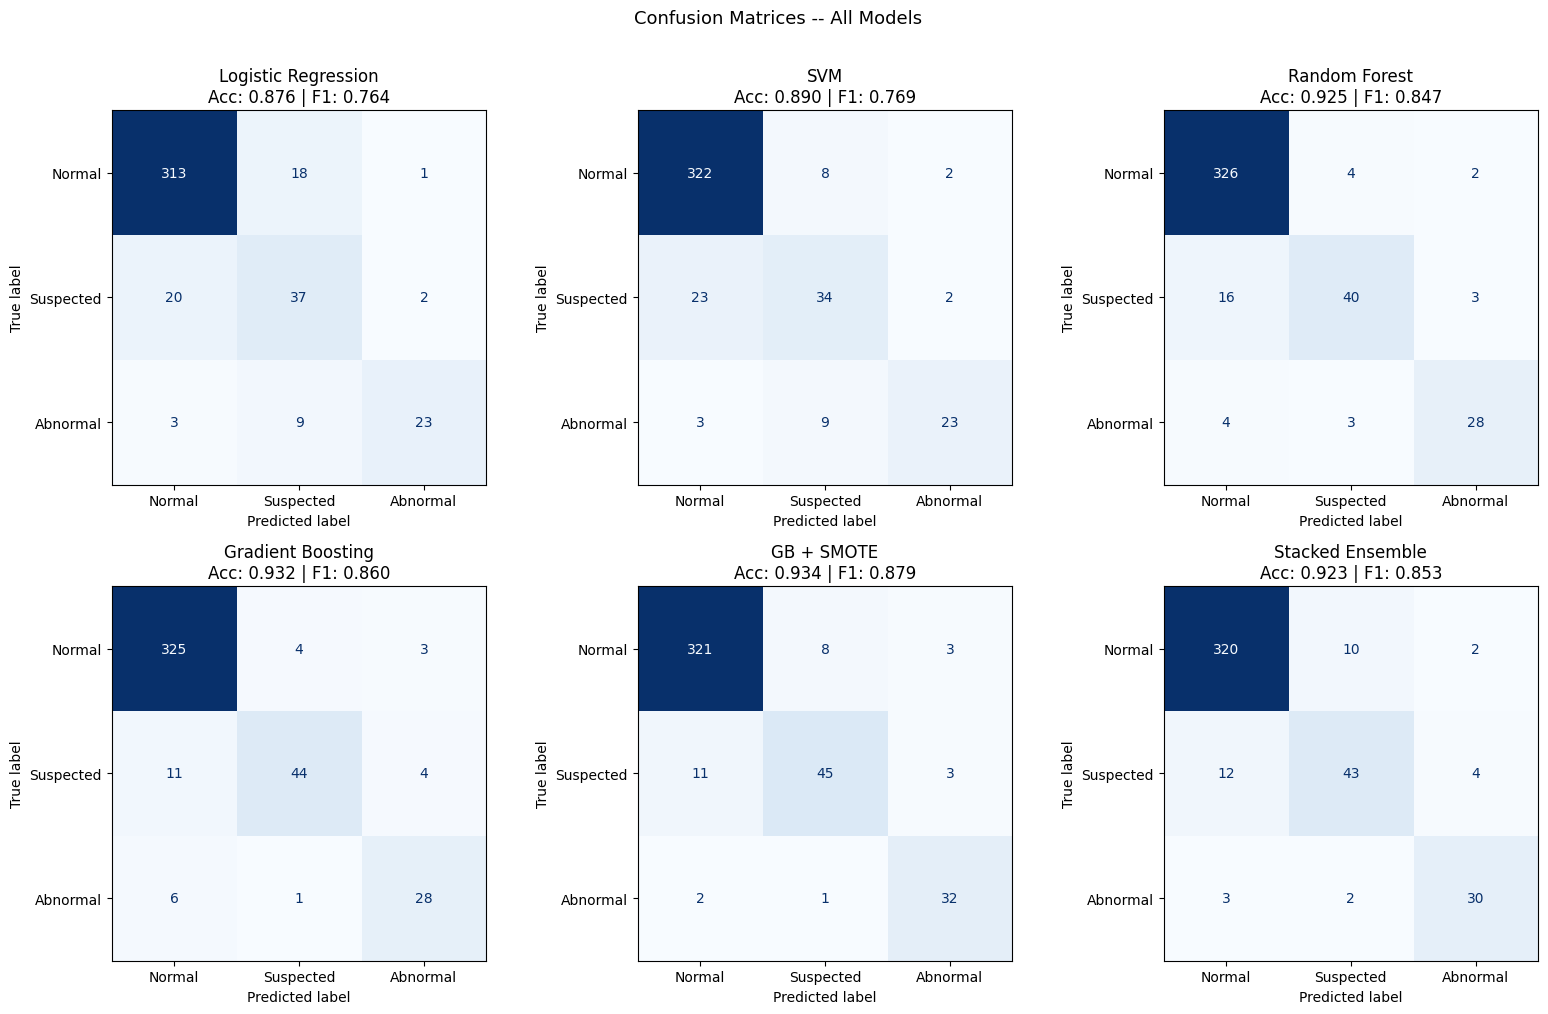

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, result) in enumerate(all_results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nAcc: {result["accuracy"]:.3f} | F1: {result["macro_f1"]:.3f}')

plt.suptitle('Confusion Matrices -- All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The side-by-side confusion matrices show the progression across all six models.

The most clinically important number -- Abnormal cases misclassified as Normal (bottom-left cell of each matrix) -- follows this progression: 3 (LR), 3 (SVM), 4 (RF), 6 (GB), 3 (Stacked Ensemble), 2 (GB + SMOTE). GB + SMOTE achieves the lowest count of this critical error.

The Stacked Ensemble shows an interesting pattern. It reduces the Abnormal-as-Normal errors to 3 (matching LR and SVM) while catching 30 Abnormal cases correctly (better than RF and GB at 28). However, it still falls short of GB + SMOTE's 32 correct with only 2 missed. On the Suspected row, the Stacked Ensemble correctly identifies 43 cases, slightly below GB + SMOTE's 45.

The Normal row is strong and stable across all models, with correct classifications ranging from 313 to 326. The slight variations reflect each model's trade-off between Normal accuracy and minority class detection.

### 5.5 Feature importance (tree-based models)

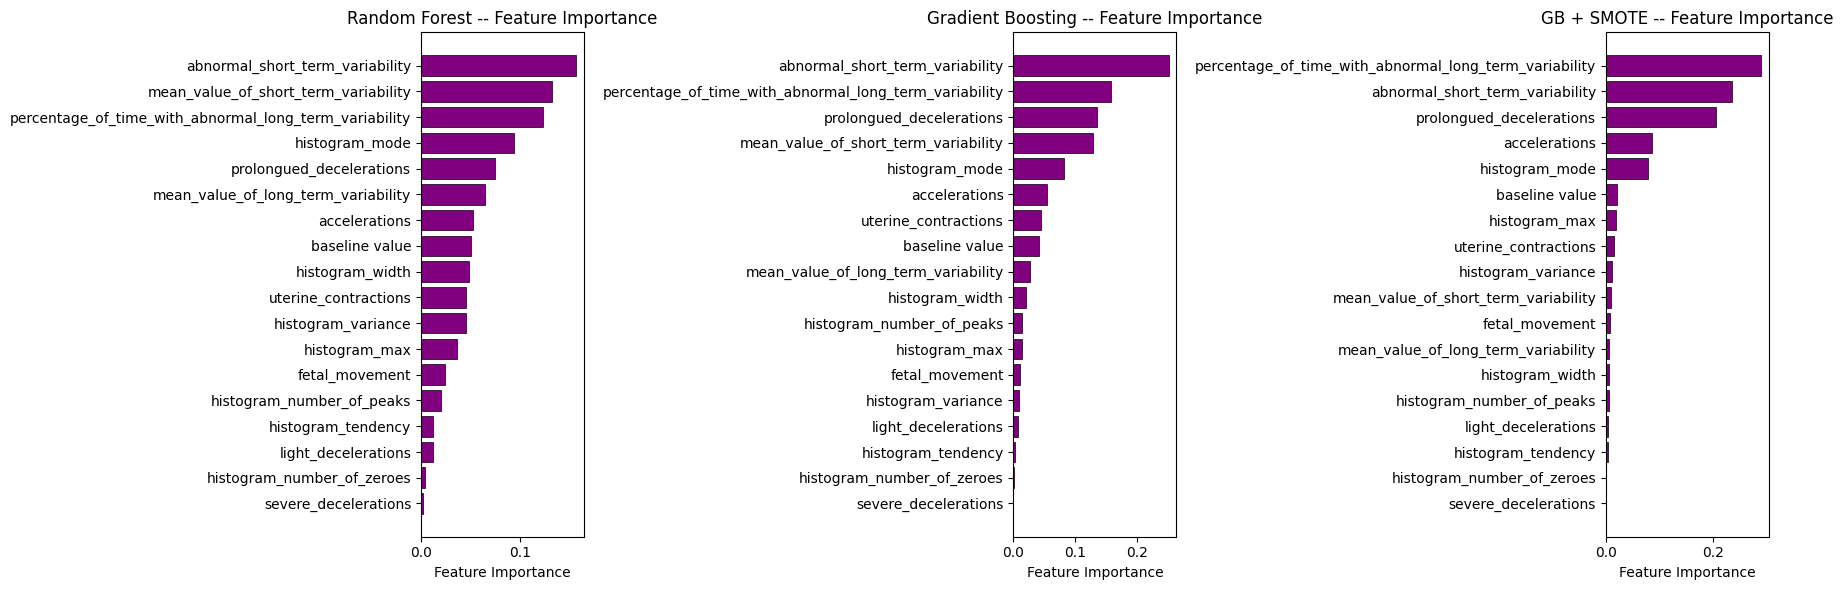

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, name in enumerate(['Random Forest', 'Gradient Boosting', 'GB + SMOTE']):
    model = all_results[name]['model']
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)

    axes[idx].barh(
        [remaining_features[i] for i in sorted_idx],
        importances[sorted_idx],
        color='purple', edgecolor='black', linewidth=0.5
    )
    axes[idx].set_xlabel('Feature Importance')
    axes[idx].set_title(f'{name} -- Feature Importance')

plt.tight_layout()
plt.show()

Understanding feature importance is central to the clinical value of this project. We want to know not just whether we can predict fetal health, but which CTG measurements matter most -- this informs clinicians about where to focus their attention when interpreting CTG traces.

Note: The Stacked Ensemble does not expose feature importance in the same direct way as individual tree-based models, because its predictions are generated by a meta-learner combining two base models' outputs. We therefore focus on the three individual tree-based models for feature importance analysis.

The three tree-based models tell a consistent story. The top predictors are dominated by variability and deceleration measures:

1. Abnormal short-term variability and percentage of time with abnormal long-term variability rank in the top three across all models. These variability indicators measure fluctuations in fetal heart rate, and their dominance confirms established clinical knowledge -- reduced or abnormal heart rate variability is one of the most reliable indicators of fetal distress.

2. Mean value of short-term variability ranks highly across all three models, reinforcing that variability measures are the strongest signal in the data.

3. Prolongued decelerations consistently ranks in the top five. Prolonged decelerations are known to be clinically significant -- they indicate sustained drops in fetal heart rate that can signal cord compression or placental insufficiency.

4. Accelerations rank in the top five for Gradient Boosting and GB + SMOTE. The presence of accelerations is generally a reassuring sign in CTG interpretation, so its importance aligns with clinical understanding.

5. Histogram mode appears in the top five for all three models, suggesting that the central tendency of the heart rate distribution carries useful signal even after dropping the redundant histogram features.

At the bottom of every chart sit severe decelerations, histogram number of zeroes, and light decelerations -- contributing very little. Severe decelerations are clinically important but extremely rare in this dataset (most values are zero). Light decelerations are generally considered benign in clinical practice, so their low ranking is consistent with medical knowledge.

The practical implication for clinicians is clear: when interpreting CTG traces, variability indicators and prolonged decelerations are the most informative measurements for identifying fetal distress.

### 5.6 Best model selection

We select **Gradient Boosting + SMOTE** as the final model based on the following evidence:

- **Highest macro F1 on the test set (0.879)**, which is our primary evaluation metric. This represents balanced performance across all three classes, not just strong Normal classification.
- **Best Abnormal recall of any model (0.914)**. The model correctly identifies 32 out of 35 Abnormal cases, with only 2 cases of genuine fetal distress misclassified as Normal. This is the most clinically critical metric.
- **Strong Suspected detection (recall: 0.76)**, with 45 out of 59 Suspected cases correctly identified.
- **Highest overall accuracy (93.4%)**, demonstrating that improving minority class detection did not come at a meaningful cost to Normal classification.

The Stacked Ensemble was tested at the suggestion of our lecturer. While it demonstrated the value of combining models -- catching 30 out of 35 Abnormal cases compared to 28 for individual tree models -- it did not outperform GB + SMOTE. This tells us that for problems with severe class imbalance, directly addressing the imbalance (SMOTE) is more impactful than combining models that all learned from the same imbalanced data. The stacking meta-learner could only be as good as its base models' combined knowledge, and those base models had the same blind spot on minority classes.

Feature importance from the final model confirms that variability indicators (abnormal short-term variability, percentage of time with abnormal long-term variability, mean short-term variability) and prolongued decelerations are the most informative CTG measurements for predicting fetal health status.

## 6. Conclusion

### Key findings

**Which CTG measurements best predict fetal health status?**

Variability indicators dominate. Abnormal short-term variability, percentage of time with abnormal long-term variability, and mean value of short-term variability were the top-ranked features across all three tree-based models. This aligns with established clinical knowledge, heart rate variability is one of the most reliable indicators of fetal well-being, and reduced variability is a recognised sign of distress.

Prolongued decelerations consistently ranked in the top five, confirming their clinical significance. Accelerations also ranked highly, which is consistent with their role as a reassuring sign in CTG interpretation.. their absence contributes to identifying at-risk cases.

Notably, severe decelerations ranked last despite being clinically significant. This is because they are extremely rare in the dataset (most values are zero), so the models had insufficient examples to learn from.. a similar pattern to red cards in football analytics.

**How well can we detect fetal distress?**

The final model (GB + SMOTE) correctly identified 91.4% of Abnormal cases, missing only 2 out of 35. This is a substantial improvement over the baseline models.. Logistic Regression and SVM caught only 65.7%, meaning roughly 1 in 3 cases of fetal distress would have been missed. The progression from 65.7% to 80.0% (tree-based models) to 91.4% (GB + SMOTE) demonstrates the value of both ensemble methods and class imbalance techniques for this problem.

**Is the Suspected class harder to classify than Normal and Abnormal?**

Yes. Suspected was the weakest class across all five models, with F1 scores ranging from 0.60 (Logistic Regression) to 0.81 (Gradient Boosting). This makes clinical sense.. Suspected cases represent a grey zone between Normal and Abnormal. Their CTG readings are not extreme enough to clearly signal distress, but they deviate enough from normal patterns to warrant concern. This ambiguity is reflected in the models' difficulty distinguishing them from both Normal and Abnormal cases.

### Recommendations

Healthcare providers: This model is best suited as a decision-support tool, not a replacement for clinical judgment. It can flag cases for further review, particularly for Abnormal detection where it catches over 91% of cases. Clinicians should focus on variability indicators and prolongued decelerations as the most informative elements of a CTG trace.

Hospital systems: Deploying this model as a screening layer could reduce inter-observer variability in CTG interpretation and ensure more consistent triage of high-risk cases. The model's low false negative rate on Abnormal cases (only 2 out of 35 missed) makes it suitable for initial screening, with clinical review for all flagged cases.

Medical researchers: Our finding that severe decelerations rank last in feature importance despite their clinical significance highlights a data limitation -- future datasets should aim to include more pathological cases to improve learning on rare but critical events.

### Limitations

- The dataset contains 2,126 records, which is relatively small for a clinical classification task. A larger dataset would improve model robustness.

- The data does not capture temporal aspects of CTG monitoring -- real-time changes in fetal heart rate patterns may carry important information that static measurements miss.

- The dataset may represent a specific population or region, and model performance may vary on data from different demographics or healthcare settings.

- Class imbalance is severe (8.3% Abnormal), and even with SMOTE, the model's performance on minority classes should be validated on external data before clinical deployment.

- This model is intended as a decision-support tool, not a replacement for clinical judgment.

### Future work

External validation: Test the model on CTG data from different hospitals, regions, and demographics to assess generalisability before any clinical deployment.

Temporal modelling: Incorporate time-series CTG data to capture how fetal heart rate patterns change over the course of monitoring, which may improve detection of developing distress.

Richer feature set: Add clinical context such as gestational age, maternal health indicators, and labour stage to test whether patient-level features improve predictions beyond CTG measurements alone.

Threshold tuning: Adjust the classification threshold for the Abnormal class to further reduce false negatives, accepting a higher false positive rate in exchange for catching the remaining 2 missed cases.

Severe deceleration enrichment: Investigate whether oversampling or targeted augmentation of cases with severe decelerations can help the model learn from these clinically important but rare events.